# Introduction

Linear regression remains one of the most widely used statistical tools in econometrics, data science, and applied economic research. In most practical applications, Ordinary Least Squares (OLS) estimation is typically used due to its simplicity, interpretability, and closed-form analytical solution.

However, classical OLS estimation may become unstable in situations involving noisy data, correlated explanatory variables, limited sample sizes, or high estimation variance. In such settings, Bayesian Linear Regression provides an alternative probabilistic framework in which model parameters are treated as random variables rather than fixed unknown quantities.

Instead of estimating a single coefficient vector, Bayesian regression combines prior beliefs with observed data in order to estimate a posterior distribution over the parameters. This probabilistic formulation naturally introduces regularization effects, uncertainty quantification, and shrinkage mechanisms closely related to Ridge regression in machine learning.

The objective of this notebook is therefore not primarily economic, but methodological. Using a real-world economic dataset related to innovation, R&D, and firm performance, this notebook aims to:

* derive OLS and Bayesian regression from first principles,
* implement both approaches from scratch,
* understand the role of prior distributions,
* explore posterior estimation and shrinkage effects,
* and study Empirical Bayes approaches based on marginal likelihood optimization.

The economic dataset is used here as an empirical case study to illustrate the statistical behavior of Bayesian regression in a realistic multivariate setting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import multivariate_normal

theme = "light" # dark

if theme=="dark":
    plt.rcParams.update({
        "figure.facecolor": "#0f0f0f",
        "axes.facecolor":   "#1a1a1a",
        "axes.edgecolor":   "#444",
        "grid.color":       "#333",
        "text.color":       "#e0e0e0",
        "axes.labelcolor":  "#e0e0e0",
        "xtick.color":      "#888",
        "ytick.color":      "#888",
        "font.family":      "monospace",
    })
else:
    plt.rcParams.update({
        "figure.facecolor": "#f5f5f5",
        "axes.facecolor":   "#ffffff",
        "axes.edgecolor":   "#cccccc",
        "grid.color":       "#dddddd",
        "text.color":       "#1f1f1f",
        "axes.labelcolor":  "#1f1f1f",
        "xtick.color":      "#666666",
        "ytick.color":      "#666666",
        "font.family":      "monospace",
    })
df = pd.read_csv("data/processed/wbes_2023_cross_section_regression.csv")
df.head()

,survey_country_wave,country_code,year,real_annual_sales_growth_pct,alt_target_labor_productivity_growth_pct,rd_spending_firms_pct,log_avg_fte_workers,avg_fte_workers,fixed_assets_purchase_firms_pct,direct_exporters_10pct_sales_pct,bank_loan_or_credit_line_firms_pct,finance_major_constraint_firms_pct,product_innovation_firms_pct,process_innovation_firms_pct,website_firms_pct,electronic_payments_made_pct,formal_training_workers_pct,quality_certification_firms_pct,electrical_outages_firms_pct
0,Bulgaria2023,BGR,2023,-2.049333,-3.694224,2.810348,3.614999,36.151314,42.290024,20.801100,31.414923,6.860053,5.391963,4.468099,53.383228,88.903511,58.592846,19.976151,20.191311
1,Bosnia and Herzegovina2023,BIH,2023,3.041226,1.464515,11.490036,3.631574,36.772213,39.527859,29.697762,42.951859,2.396534,7.830256,1.288629,87.410286,94.660500,57.013615,28.411245,14.629148
2,Barbados2023,BRB,2023,24.474562,16.845270,5.382697,3.426254,29.761181,23.588665,6.807787,26.927402,3.715828,32.529655,10.922821,87.302971,73.326645,70.783394,2.916544,63.027424
3,Botswana2023,BWA,2023,18.933216,16.672300,6.196696,3.619135,36.305298,27.458305,6.253392,23.103045,20.261272,20.267054,9.572171,45.899410,69.778625,58.331814,10.402226,64.157768
4,Central African Republic2023,CAF,2023,19.439695,18.415405,44.255253,3.148504,22.301170,35.611797,18.884058,8.852996,53.822803,27.860859,8.702892,24.328218,18.889315,21.358131,0.111369,89.279549


In [2]:
y = df['real_annual_sales_growth_pct'].to_numpy()
X = df[[
    'rd_spending_firms_pct',
    # 'log_avg_fte_workers',
    # 'fixed_assets_purchase_firms_pct',
    # 'direct_exporters_10pct_sales_pct',
    # 'bank_loan_or_credit_line_firms_pct',
    # 'finance_major_constraint_firms_pct',
    'product_innovation_firms_pct',
    # 'process_innovation_firms_pct',
    # 'website_firms_pct',
    # 'electronic_payments_made_pct',
    # 'formal_training_workers_pct',
]].to_numpy()
# adding intercept
X = np.hstack([np.ones((X.shape[0], 1)), X])
y.shape, X.shape

((39,), (39, 3))

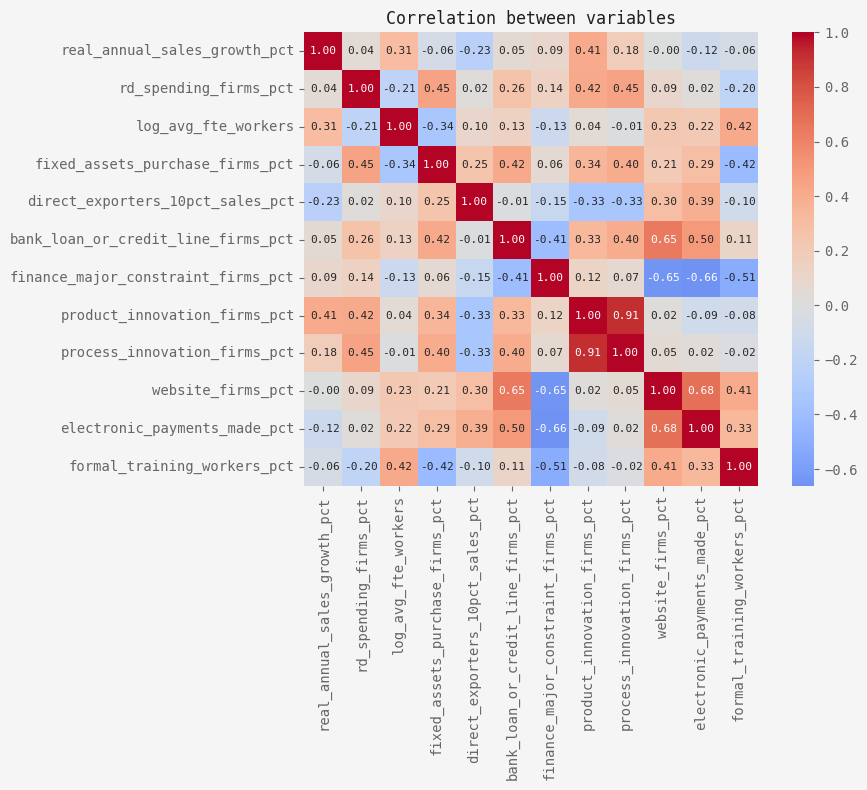

In [3]:
# Correlation matrix on target + predictors
selected_cols = [
    'real_annual_sales_growth_pct',
    'rd_spending_firms_pct',
    'log_avg_fte_workers',
    'fixed_assets_purchase_firms_pct',
    'direct_exporters_10pct_sales_pct',
    'bank_loan_or_credit_line_firms_pct',
    'finance_major_constraint_firms_pct',
    'product_innovation_firms_pct',
    'process_innovation_firms_pct',
    'website_firms_pct',
    'electronic_payments_made_pct',
    'formal_training_workers_pct',
]
corr_df = df[selected_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    annot_kws={'size': 8},
 )
plt.title('Correlation between variables')
plt.tight_layout()

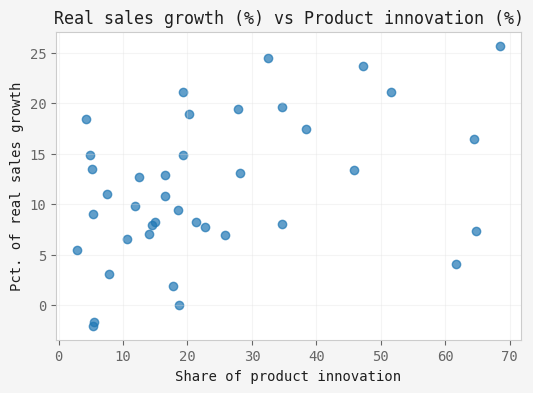

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df['product_innovation_firms_pct'], 
    df['real_annual_sales_growth_pct'], 
    alpha=0.7
)
plt.title("Real sales growth (%) vs Product innovation (%)")
plt.ylabel("Pct. of real sales growth")
plt.xlabel("Share of product innovation")
plt.grid(alpha=0.3)
plt.show()


The dataset is a cross-sectional economic dataset containing innovation and firm-performance indicators across multiple economies in 2023. It includes variables related to real annual sales growth, R&D spending, process innovation, and firm size.

The dataset is used as an empirical case study to illustrate and compare OLS and Bayesian Linear Regression methods in a realistic multivariate economic setting.

# OLS Regression

## The Model

Ordinary Least Squares (OLS) regression aims to estimate the linear relationship between a dependent variable ($y$) and a set of explanatory variables ($X$). The objective is to find the coefficient vector ($\beta$) that minimizes the sum of squared residuals between observed and predicted values.

In [5]:
# Using a random coefficient we have
np.random.seed(42)  # For reproducibility
beta_random = np.random.randn(X.shape[1])

# Linear prediction
y_pred_random = X @ beta_random

print(beta_random)
print("Model Equation using random coefficients:")
print(f"    y = {beta_random[0]:.2f} + {beta_random[1]:.2f} * rd_spending_firms + {beta_random[2]:.2f} * product_innovation_firms")

[ 0.49671415 -0.1382643   0.64768854]
Model Equation using random coefficients:
    y = 0.50 + -0.14 * rd_spending_firms + 0.65 * product_innovation_firms


In [6]:
def regression_plot(df, x_col, y_col, z_col, beta, grid_size=20, title=None, labels=None):
    if labels is None:
        labels = {
            x_col: x_col,
            y_col: y_col,
            z_col: z_col,
        }
    fig = px.scatter_3d(
        df,
        x=x_col,
        y=y_col,
        z=z_col,
        title=title,
        labels=labels,
    )
    x_range = np.linspace(df[x_col].min(), df[x_col].max(), grid_size)
    y_range = np.linspace(df[y_col].min(), df[y_col].max(), grid_size)
    x_grid, y_grid = np.meshgrid(x_range, y_range)
    z_grid = beta[0] + beta[1] * x_grid + beta[2] * y_grid
    surface = go.Surface(x=x_range, y=y_range, z=z_grid, opacity=0.5, showscale=False)
    fig.add_traces([surface])
    return fig


In [7]:
fig = regression_plot(
    df,
    x_col='rd_spending_firms_pct',
    y_col='product_innovation_firms_pct',
    z_col='real_annual_sales_growth_pct',
    beta=beta_random,
    title="Random linear model: sales growth vs R&D spending and product innovation",
    labels={
        'rd_spending_firms_pct': 'R&D spending (%)',
        'product_innovation_firms_pct': 'Product innovation (%)',
        'real_annual_sales_growth_pct': 'Real sales growth (%)',
    }
)
fig.show()

## Estimator

The closed-form OLS estimator is given by:

$$\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$$

In [8]:
# So we have:
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y
print("Model Equation using OLS coefficients:")
print(f"    y = {beta_ols[0]:.2f} + {beta_ols[1]:.2f} * rd_spending_firms + {beta_ols[2]:.2f} * product_innovation_firms")

Model Equation using OLS coefficients:
    y = 8.89 + -0.12 * rd_spending_firms + 0.18 * product_innovation_firms


In [9]:
fig = regression_plot(
    df,
    x_col='rd_spending_firms_pct',
    y_col='product_innovation_firms_pct',
    z_col='real_annual_sales_growth_pct',
    beta=beta_ols,
    title="OLS linear model: sales growth vs R&D spending and product innovation",
    labels={
        'rd_spending_firms_pct': 'R&D spending (%)',
        'product_innovation_firms_pct': 'Product innovation (%)',
        'real_annual_sales_growth_pct': 'Real sales growth (%)',
    }
)
fig.show()

## Implementation

In [10]:
class OLSRegression:
    def __init__(self, X, y):
        self.beta = None
        self.X = X
        self.y = y
    
    def fit(self):
        self.beta = np.linalg.inv(self.X.T @ self.X) @ self.X.T @ self.y
        
    def summary(self, feature_names=None):
        from scipy import stats
        import pandas as pd

        if self.beta is None:
            raise ValueError("Model not fitted yet.")

        n, k = self.X.shape

        y_pred = self.X @ self.beta
        residuals = self.y - y_pred

        # sums of squares
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((self.y - np.mean(self.y))**2)
        ss_reg = ss_tot - ss_res

        # goodness of fit
        r_squared = 1 - ss_res / ss_tot
        adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k)

        # residual variance
        sigma_squared = ss_res / (n - k)
        self.sigma_squared = sigma_squared

        # variance covariance matrix
        var_beta = sigma_squared * np.linalg.inv(self.X.T @ self.X)

        # std errors
        se_beta = np.sqrt(np.diag(var_beta))

        # t-stats
        t_stats = self.beta / se_beta

        # p-values
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-k))

        # F-stat
        f_stat = (ss_reg / (k - 1)) / (ss_res / (n - k))
        f_pvalue = 1 - stats.f.cdf(f_stat, k - 1, n - k)

        # feature names
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(k)]

        # coefficients table
        coef_table = pd.DataFrame({
            "Estimate": self.beta,
            "Std. Error": se_beta,
            "t value": t_stats,
            "Pr(>|t|)": p_values
        }, index=feature_names)

        print()
        print("=" * 70)
        print("OLS Regression Results")
        print("=" * 70)
        print(coef_table.round(4))
        print("-" * 70)
        print(f"Residual standard error: {np.sqrt(sigma_squared):.4f} on {n-k} DF")
        print(f"Multiple R-squared: {r_squared:.4f}")
        print(f"Adjusted R-squared: {adj_r_squared:.4f}")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"Prob (F-statistic): {f_pvalue:.4g}")   
    
    def get_coefficients(self):
        if self.beta is None:
            raise ValueError("Model not fitted yet.")
        return self.beta, self.sigma_squared

In [11]:
linear_regression = OLSRegression(X, y)
linear_regression.fit()
feature_names = ['intercept', 'R&D spending (%)', 'Product innovation (%)']
linear_regression.summary(feature_names=feature_names)


OLS Regression Results
                        Estimate  Std. Error  t value  Pr(>|t|)
intercept                 8.8942      2.1216   4.1922    0.0002
R&D spending (%)         -0.1214      0.1293  -0.9390    0.3540
Product innovation (%)    0.1812      0.0636   2.8472    0.0072
----------------------------------------------------------------------
Residual standard error: 6.6170 on 36 DF
Multiple R-squared: 0.1853
Adjusted R-squared: 0.1401
F-statistic: 4.0947
Prob (F-statistic): 0.02499


In [12]:
# conf_interval for R&D spending coefficient:
beta_rd = linear_regression.get_coefficients()[0][1]  # beta[1] = coef R&D
se_rd = 0.1293  # from summary output
ci_lower = beta_rd - 1.96 * se_rd
ci_upper = beta_rd + 1.96 * se_rd
print(f"95% confidence interval for R&D spending coefficient: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% confidence interval for R&D spending coefficient: [-0.3748, 0.1321]


## Results & OLS Limits

**R&D spending : $\hat\beta = -0.12$ (SE $=0.13$, $p=0.35$).**
Holding product innovation constant, a 1-point increase in the share of R&D-active firms is associated with a 0.12-point *decrease* in sales growth.
The estimate is statistically indistinguishable from zero: the standard error exceeds the coefficient in absolute value, and the 95% confidence interval $[-0.38,\,0.14]$ even **changes sign**.

This is a textbook setting for Bayesian regression: 
* a small sample ($n=39$), 
* correlated regressors, 
* and high estimation variance. 

Rather than a binary "not significant" verdict, the Bayesian approach will return a full posterior distribution and credible interval, while shrinking this weak, noisy coefficient toward the prior (the effect we explore next).



## Prior

This is where we can inject our prior beliefs about the likely magnitude and direction of the R&D spending effect, based on theory, previous studies, or domain knowledge.

For example, we might believe that R&D spending should have a positive effect on sales growth, based on economic theory and prior empirical evidence. We could encode this belief in a prior distribution that is centered around a positive value (e.g., from linear regression results a normal distribution with mean -0.12 and standard deviation 0.13). This would reflect our expectation that the true effect of R&D spending is likely to be positive, while still allowing for uncertainty around that estimate.

So we suppose: $$\beta_{R\&D} \sim \mathcal{N}(\mu=-0.12, \sigma=0.13)$$

Prior mean: [ 0.   -0.12  0.  ]
Prior covariance:
 [[10.    0.    0.  ]
 [ 0.    0.13  0.  ]
 [ 0.    0.    1.  ]]


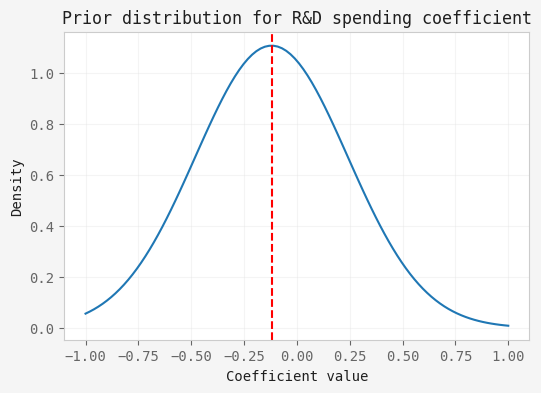

In [13]:
# prior on beta
beta_prior_mean = np.array([0, -0.12, 0])  # Prior mean for intercept, R&D spending, and product innovation
beta_prior_cov = np.diag([10, 0.13, 1])  # Prior covariance (more uncertainty on intercept, less on predictors)
print("Prior mean:", beta_prior_mean)
print("Prior covariance:\n", beta_prior_cov)

# Plotting the prior distribution for the R&D spending coefficient
beta_range = np.linspace(-1, 1, 100)
prior_rd = multivariate_normal(mean=beta_prior_mean[1], cov=beta_prior_cov[1, 1]).pdf(beta_range)
plt.figure(figsize=(6, 4))
plt.plot(beta_range, prior_rd, label='Prior distribution for R&D coefficient')
plt.title("Prior distribution for R&D spending coefficient")
plt.xlabel("Coefficient value")
plt.ylabel("Density")
plt.axvline(-0.12, color='red', linestyle='--', label='Prior mean = -0.12')
plt.grid(alpha=0.3)
plt.show()

## Posterior and credible interval

This is where the magic happens: we combine the likelihood from our data with the prior to get the posterior distribution of the coefficients, which reflects both our prior beliefs and the evidence from the data.

Some of the R&D spending coefficient's "signal" is likely to be noise, and the Bayesian approach will shrink it toward our prior belief of a negative effect, while still allowing for the possibility of a positive effect if the data strongly suggests it.

So:
$$\beta | y, X \sim \mathcal{N}(\mu_{post}, \Sigma_{post})$$
with:
$$\Sigma_{post} = (\frac{1}{\sigma^2} X^TX + \Sigma_{prior}^{-1})^{-1}$$
$$\mu_{post} = \Sigma_{post} (\frac{1}{\sigma^2} X^Ty + \Sigma_{prior}^{-1} \mu_{prior})$$


Estimated error variance (sigma^2): 43.7849
Posterior mean: [ 6.20967522 -0.03558253  0.21273594]
Posterior covariance:
 [[ 3.02452355 -0.09557243 -0.03628203]
 [-0.09557243  0.01348707 -0.00355638]
 [-0.03628203 -0.00355638  0.00376324]]


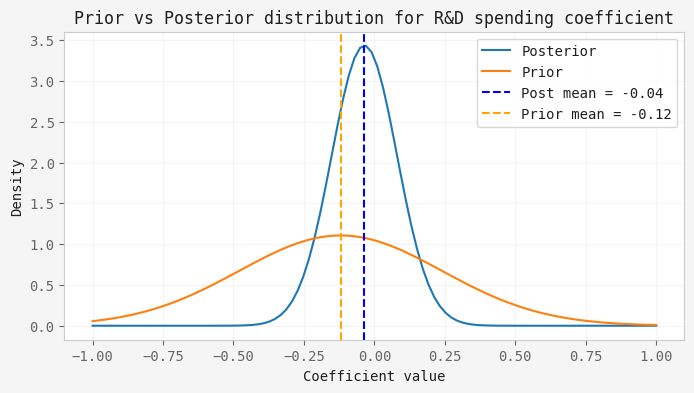

In [14]:
sigma_squared = linear_regression.get_coefficients()[1]
print(f"Estimated error variance (sigma^2): {sigma_squared:.4f}")

# posterior parameters
XTX = X.T @ X
XTy = X.T @ y
cov_posterior = np.linalg.inv(XTX / sigma_squared + np.linalg.inv(beta_prior_cov))
mean_posterior = cov_posterior @ (XTy / sigma_squared + np.linalg.inv(beta_prior_cov) @ beta_prior_mean)
print("Posterior mean:", mean_posterior)
print("Posterior covariance:\n", cov_posterior)

# Plotting the prior and posterior distribution for the R&D spending coefficient
posterior_rd = multivariate_normal(mean=mean_posterior[1], cov=cov_posterior[1, 1]).pdf(beta_range)
plt.figure(figsize=(8, 4))
plt.plot(beta_range, posterior_rd, label='Posterior')
plt.plot(beta_range, prior_rd, label='Prior')
plt.title("Prior vs Posterior distribution for R&D spending coefficient")
plt.xlabel("Coefficient value")
plt.ylabel("Density")
plt.axvline(mean_posterior[1], color='blue', linestyle='--', label='Post mean = {:.2f}'.format(mean_posterior[1]))
plt.axvline(-0.12, color='orange', linestyle='--', label='Prior mean = -0.12')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [15]:
# confidence interval for posterior
ci_lower_post = mean_posterior[1] - 1.96 * np.sqrt(cov_posterior[1, 1])
ci_upper_post = mean_posterior[1] + 1.96 * np.sqrt(cov_posterior[1, 1])
print(f"95% credible interval for R&D spending coefficient: [{ci_lower_post:.4f}, {ci_upper_post:.4f}]")

95% credible interval for R&D spending coefficient: [-0.2632, 0.1920]


**Results Interpretation**:
The posterior distribution for the R&D spending coefficient is more concentrated around zero compared to the prior, reflecting the data's information.
The posterior mean is equal to $-O.04$ with a 95% credible interval of $[-0.2632, 0.1920]$, which still includes zero but is narrower than the prior interval.
In this case, the Bayesian analysis confirms the OLS result: there is no strong evidence of a positive or negative effect of R&D spending on sales growth, and the data is consistent with a wide range of possible effects, including zero.

## Implementation

In [16]:
class BayesianRegression:
    def __init__(self, X, y, beta_prior_mean, beta_prior_cov):
        self.X = X
        self.y = y
        self.beta_prior_mean = beta_prior_mean
        self.beta_prior_cov = beta_prior_cov
        self.beta_posterior_mean = None
        self.beta_posterior_cov = None
    
    def fit(self):
        sigma_squared = np.var(self.y - self.X @ np.linalg.inv(self.X.T @ self.X) @ self.X.T @ self.y)
        XTX = self.X.T @ self.X
        XTy = self.X.T @ self.y
        self.beta_posterior_cov = np.linalg.inv(XTX / sigma_squared + np.linalg.inv(self.beta_prior_cov))
        self.beta_posterior_mean = self.beta_posterior_cov @ (XTy / sigma_squared + np.linalg.inv(self.beta_prior_cov) @ self.beta_prior_mean)
    
    def summary(self, feature_names=None):
        from scipy import stats
        if self.beta_posterior_mean is None or self.beta_posterior_cov is None:
            raise ValueError("Model not fitted yet.")
        
        # building summary table
        se_posterior = np.sqrt(np.diag(self.beta_posterior_cov))
        t_stats = self.beta_posterior_mean / se_posterior
        p_values = 2 * (1 - stats.norm.cdf(np.abs(t_stats)))
        
        # metrics
        n = self.y.shape[0]
        y_pred = self.X @ self.beta_posterior_mean
        residuals = self.y - y_pred
        
        # sums of squares
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((self.y - np.mean(self.y))**2)
        
        # goodness of fit
        r_squared = 1 - ss_res / ss_tot
        adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - self.X.shape[1])
        
        # F-statistic
        f_stat = (ss_tot - ss_res) / (self.X.shape[1] - 1) / (ss_res / (n - self.X.shape[1]))
        f_pvalue = 1 - stats.f.cdf(f_stat, self.X.shape[1] - 1, n - self.X.shape[1])
        
        # feature names
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(self.X.shape[1])]
        summary_table = pd.DataFrame({
            "Posterior Mean": self.beta_posterior_mean,
            "Std. Error": se_posterior,
            "t value": t_stats,
            "Pr(>|t|)": p_values
        }, index=feature_names)
        print()
        print("=" * 70)
        print("Bayesian Regression Results")
        print("=" * 70)
        print(summary_table.round(4))
        print("-" * 70)
        print(f"Residual standard error: {np.sqrt(ss_res / (n - self.X.shape[1])):.4f} on {n - self.X.shape[1]} DF")
        print(f"Multiple R-squared: {r_squared:.4f}")
        print(f"Adjusted R-squared: {adj_r_squared:.4f}")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"Prob (F-statistic): {f_pvalue:.4g}")
        print(f"Posterior covariance matrix:\n{self.beta_posterior_cov}")
    
    def get_posterior(self):
        if self.beta_posterior_mean is None or self.beta_posterior_cov is None:
            raise ValueError("Model not fitted yet.")
        return self.beta_posterior_mean, self.beta_posterior_cov

In [17]:
beta_ols, sigma_squared = linear_regression.get_coefficients()
print(f"Estimated error variance (sigma^2): {sigma_squared:.4f}")
linear_regression.summary(feature_names=feature_names)

# Using OLS estimates as prior mean and the estimated error variance to set the prior covariance
beta_prior_mean = np.array([0.0, 0.0, 0.0])  # Non-informative prior mean
beta_prior_cov = np.diag([10, 1, 1])  # More uncertainty on intercept, less on predictors
bayesian_regression = BayesianRegression(X, y, beta_prior_mean, beta_prior_cov)
bayesian_regression.fit()
bayesian_regression.summary(feature_names=feature_names)

Estimated error variance (sigma^2): 43.7849

OLS Regression Results
                        Estimate  Std. Error  t value  Pr(>|t|)
intercept                 8.8942      2.1216   4.1922    0.0002
R&D spending (%)         -0.1214      0.1293  -0.9390    0.3540
Product innovation (%)    0.1812      0.0636   2.8472    0.0072
----------------------------------------------------------------------
Residual standard error: 6.6170 on 36 DF
Multiple R-squared: 0.1853
Adjusted R-squared: 0.1401
F-statistic: 4.0947
Prob (F-statistic): 0.02499

Bayesian Regression Results
                        Posterior Mean  Std. Error  t value  Pr(>|t|)
intercept                       6.2869      1.7101   3.6764    0.0002
R&D spending (%)               -0.0306      0.1174  -0.2607    0.7943
Product innovation (%)          0.2085      0.0598   3.4895    0.0005
----------------------------------------------------------------------
Residual standard error: 6.7544 on 36 DF
Multiple R-squared: 0.1511
Adjusted R-squ

## Ridge Regression / Independent priors

Past, we used a non-informative prior with large variance for all coefficients. This is equivalent to OLS regression.

But we can also use more informative priors, for example by setting a smaller variance on the R&D spending coefficient. This is equivalent to ridge regression, where we shrink the coefficient towards zero (or any other prior mean) based on the strength of the prior.

If we take an independant prior on the coefficients:
$$\beta_j \sim \mathcal{N}(0, \tau^2I)$$
So:
$$\Sigma_0 = \tau^2I \implies \Sigma_0^{-1} = \frac{1}{\tau^2}I$$

We obtain the posterior mean:
$$\Sigma_{post} = (\frac{1}{\sigma^2}X^TX + \frac{1}{\tau^2}I)^{-1}$$
($\frac{1}{\tau^2}I$ which is equivalent to the `np.linalg.inv(self.beta_prior_cov)` in BayesianRegression)
$$\Beta_{post} = \Sigma_{post} (\frac{1}{\sigma^2}X^Ty)$$

same as:
$$\Beta_{post} = (X^T X + \frac{\sigma^2}{\tau^2}I)^{-1}X^T y$$

With $\lambda = \frac{\sigma^2}{\tau^2}$:
$$\Beta_{post} = (X^T X + \lambda I)^{-1}X^T y$$

And this is exactly the Ridge Regression

In [18]:
class RidgeRegression:
    def __init__(self, X, y, lambda_):
        self.X = X
        self.y = y
        self.lambda_ = lambda_
        self.beta = None
        self.sigma_squared = None
    
    def fit(self):
        n, k = self.X.shape
        I = np.eye(k)
        I[0, 0] = 0  # To not penalize the intercept
        self.beta = np.linalg.inv(self.X.T @ self.X + self.lambda_ * I) @ self.X.T @ self.y
        self.sigma_squared = np.sum((self.y - self.X @ self.beta)**2) / (n - k)
        self.standard_errors = np.sqrt(np.diag(np.linalg.inv(self.X.T @ self.X + self.lambda_ * I) * self.sigma_squared))
        
    def summary(self, feature_names=None):
        if self.beta is None:
            raise ValueError("Model not fitted yet.")
        
        # feature names
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(self.X.shape[1])]
        
        coef_table = pd.DataFrame({
            "Coefficient": self.beta,
            "Standard Error": self.standard_errors
        }, index=feature_names)
        
        print()
        print("=" * 70)
        print(f"Ridge Regression Results (lambda={self.lambda_})")
        print("=" * 70)
        print(coef_table.round(4))
    
    def get_coefficients(self):
        if self.beta is None:
            raise ValueError("Model not fitted yet.")
        return self.beta, self.sigma_squared

ridge_regression = RidgeRegression(X, y, lambda_=1.0)
ridge_regression.fit()
ridge_regression.summary(feature_names=feature_names)


Ridge Regression Results (lambda=1.0)
                        Coefficient  Standard Error
intercept                    8.8939          2.1215
R&D spending (%)            -0.1213          0.1292
Product innovation (%)       0.1812          0.0636


# Empirical Bayes


## Problem

<figure style="text-align:center;">
  <img src="img/ridge_coefficients.png" alt="Ridge coefficients by lambda" style="max-width:100%; height:auto;">
  <figcaption>
    This plot shows the variation of the distribution across different "lambda" (prior parameter) in Ridge Regression.
  </figcaption>
</figure>


Recently, we have seen how to perform Bayesian regression using a specified prior distribution. However, in many cases, we may not have strong prior beliefs about the parameters or may want to use the data itself to inform our prior. This is where empirical Bayes comes in.

Empirical Bayes is a method that allows us to estimate the prior distribution from the data, rather than specifying it a priori. This can be particularly useful when we have limited prior knowledge or when we want to use the data to inform our beliefs about the parameters.


## Marginal Likelihood

The marginal likelihood (or evidence) is the probability of the observed data under the model, integrating out the parameters. For a Bayesian linear regression with a Gaussian likelihood and a Gaussian prior, the marginal likelihood can be computed in closed form.

We have:
$$
\begin{cases}
y = X\beta + \epsilon \\
\beta \sim \mathcal{N}(0, \tau^2 I) \\
\epsilon \sim \mathcal{N}(0, \sigma^2 I)
\end{cases}
\;\Rightarrow\;
y \sim \mathcal{N}(0, \sigma^2 I + \tau^2 XX^T)
$$

The marginal likelihood is given by:
$$p(y | X, \tau^2) = \mathcal{N}(y | 0, \Sigma_y)$$
with $\Sigma_y = \sigma^2 I + \tau^2 XX^T$.

### **Log Marginal Likelihood**
To avoid numerical issues, we often work with the log marginal likelihood, that we will maximize with respect to $\tau^2$ to find the optimal prior variance in an Empirical Bayes approach.

$$
log p(y | X, \tau^2) = -\frac{1}{2} \left( n \log(2\pi) + \log|\Sigma_y| + y^T \Sigma_y^{-1} y \right)
$$


#### **Conceptual simplification**
Invert $\Sigma_y (n \times n)$ can be computationally expensive, but we can use the [Woodbury identity](https://en.wikipedia.org/wiki/Woodbury_matrix_identity) to simplify the computation since $\Sigma_y$ has a special structure:

$$\Sigma_y^{-1} = \frac{1}{\sigma^2} I - \frac{\tau^2}{\sigma^4} X (I + \frac{\tau^2}{\sigma^2} X^T X)^{-1} X^T$$


#### **Caution:**
> The empirical Bayes approach is different from the fully Bayesian approach where we would put a hyperprior on $\tau^2$ and integrate it out. In empirical Bayes, we treat $\tau^2$ as a fixed parameter to be estimated from the data, which can lead to overfitting if not done carefully.


## Implementation

In [19]:
class EmpiricalBayesianRegression:
    def __init__(self, X, y, sigma_squared=None):
        self.X = X
        self.y = y
        self.beta = None
        self.cov = None
        self.optimal_tau2 = None
        self.lml = self.log_marginal_likelihood
        self.sigma_squared = sigma_squared
        if self.sigma_squared is None:
            beta_ols = np.linalg.lstsq(self.X, self.y, rcond=None)[0]
            residuals = self.y - self.X @ beta_ols
            n, k = self.X.shape
            self.sigma_squared = (residuals @ residuals) / (n - k)
    
    def log_marginal_likelihood(self, tau2):
        n = self.X.shape[0]
        sigma2 = self.sigma_squared
        sigma_y = sigma2 * np.eye(n) + tau2 * (self.X @ self.X.T)
        # Cholesky for log-det and quadratic form (cf. cholesky_decomposition.md)
        jitter = 1e-8
        L = np.linalg.cholesky(sigma_y + jitter * np.eye(n))
        alpha = np.linalg.solve(L, self.y)
        quad = alpha @ alpha
        log_det = 2.0 * np.sum(np.log(np.diag(L)))
        return -0.5 * (n * np.log(2.0 * np.pi) + log_det + quad)
    
    def optimize(self, tau2_range=[1e-6, 100], summary=False):
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(lambda t: -self.log_marginal_likelihood(t), bounds=tau2_range, method='bounded')
        
        if summary:
            print(f"Optimal tau^2: {res.x:.6f}")
            print(f"Log marginal likelihood at optimal tau^2: {-res.fun:.4f}")
        
        self.optimal_tau2 = res.x
        return self.optimal_tau2
    
    def fit(self):
        tau2 = self.optimal_tau2
        if tau2 is None:
            raise ValueError("Call optimize() before fit().")
        XTX = self.X.T @ self.X
        XTy = self.X.T @ self.y
        k = self.X.shape[1]
        sigma2 = self.sigma_squared
        prior_prec = np.eye(k) / tau2
        self.cov = np.linalg.inv(XTX / sigma2 + prior_prec)
        self.beta = self.cov @ (XTy / sigma2)
        
    def predict(self, X_new):
        if self.beta is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return X_new @ self.beta
    
    def summary(self, feature_names=None):
        if self.beta is None or self.cov is None:
            raise ValueError("Model not fitted yet.")
        
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(self.X.shape[1])]
        
        se_beta = np.sqrt(np.diag(self.cov))
        coef_table = pd.DataFrame({
            "Coefficient": self.beta,
            "Std. Error": se_beta
        }, index=feature_names)

        print()
        print("=" * 70)
        print("Empirical Bayesian Regression Results")
        print("=" * 70)
        print(coef_table.round(4))
        print(f"Posterior covariance matrix:\n{self.cov}")

In [20]:
ebr = EmpiricalBayesianRegression(X, y)
ebr.optimize(tau2_range=[1e-6, 1000], summary=True)
ebr.fit()
ebr.summary(feature_names=feature_names)

Optimal tau^2: 18.155224
Log marginal likelihood at optimal tau^2: -138.5818

Empirical Bayesian Regression Results
                        Coefficient  Std. Error
intercept                    7.1272      1.8990
R&D spending (%)            -0.0607      0.1251
Product innovation (%)       0.2002      0.0628
Posterior covariance matrix:
[[ 3.60603437 -0.12365994 -0.03893878]
 [-0.12365994  0.01564186 -0.00379318]
 [-0.03893878 -0.00379318  0.00394375]]


# Comparison

## Coefficients (Std. Error in parentheses)

| Coefficient | OLS | Ridge ($\lambda=1$) | Bayesian | Empirical Bayes |
|---|---|---|---|---|
| Intercept | 8.894 (2.122) | 8.894 (2.122) | 6.287 (1.710) | 7.127 (1.899) |
| **R&D spending (%)** | **−0.121 (0.129)** | **−0.121 (0.129)** | **−0.031 (0.117)** | **−0.061 (0.125)** |
| Product innovation (%) | 0.181 (0.064) | 0.181 (0.064) | 0.209 (0.060) | 0.200 (0.063) |

**Std errors in parenthesis*

## Fit

| Metric | OLS | Bayesian |
|---|---|---|
| Residual std. error | 6.617 | 6.754 |
| Multiple $R^2$ | 0.185 | 0.151 |
| Adjusted $R^2$ | 0.140 | 0.104 |
| F-statistic | 4.095 | 3.205 |
| Prob (F) | 0.025 | 0.052 |

## Reading the tables

- **Ridge at $\lambda=1 \approx$ OLS**: the penalty is too weak to regularize anything (−0.1213 vs −0.1214). Useful to show that shrinkage depends on the strength of the prior.
- **Shrinkage hits the weak/noisy coefficient hardest**: R&D moves from −0.121 (OLS) to −0.031 (Bayes), pulled toward 0 by ~75%, while product innovation (strong signal) barely moves (0.181 → 0.209) and stays stable. This is exactly the expected behavior: 
  the Bayesian estimator pulls poorly identified coefficients toward the prior and leaves the others alone.
- **All standard errors shrink** under the Bayesian model (R&D: 0.129 → 0.117; innovation:
  0.064 → 0.060), a reduction in estimation variance, at the cost of a small bias
  (bias–variance trade-off).
- **Empirical Bayes is intermediate**: the prior strength is learned from the data (by maximizing the marginal likelihood), so the shrinkage is more moderate than a fixed prior, R&D stops at −0.061.
- **Fit drops slightly** ($R^2$ 0.185 → 0.151): expected, since regularization sacrifices some in-sample fit for robustness.

# Conclusion

This notebook built Bayesian linear regression from the ground up and placed it a common axis with OLS and Ridge: a flat prior recovers OLS, a zero-mean Gaussian prior is exactly Ridge ($\lambda=\sigma^2/\tau^2$), and Empirical Bayes learns the prior strength from the data by maximizing the marginal likelihood. The payoff of the method is structural: parameters become distributions, so it returns credible intervals and shrinks weak, poorly identified coefficients toward the prior while leaving well-identified ones untouched. The R&D example simply made these mechanics visible on real data.
